# Final Project: Retrieval-Augmented Generation (RAG)
---

## Overview

In this assignment, you will gain hands-on experience in implementing a Retrieval-Augmented Generation (RAG) pipeline. This technique combines the power of retrieval systems and language models to generate contextually accurate responses by searching through external documents. RAG is particularly useful in business applications for improving customer support, summarization, and information retrieval tasks. You will use **LangChain**, a popular framework for building applications with language models, and **YandexGPT**, a large language model (LLM) for generating answers to both manually created and automatically generated questions.

## Task breakdown

### Task 1: Collect Relevant Articles. __1 point__
1. **Download 8-10 articles** related to **Natural Language Processing (NLP)** and **Computer Vision (CV)** from:
   - [arxiv.org](https://arxiv.org)
   - [paperswithcode.com](https://paperswithcode.com)
   - Any other scholarly web resource of your choice
   
   These articles will form the basis of your retrieval-augmented generation pipeline. Be sure to choose recent and impactful papers that represent real-world applications in NLP and CV.  
   Use `requests`, `urllib` or any other python library for documents downloading.

### Task 2: Formulate Questions. __1 point__
2. For each of the downloaded articles **come up with one meaningful question** based on the content of the article. These questions should focus on the main ideas, key challenges, or results presented in the paper.

### Task 3: Generate Additional Questions using LangChain. __8 points__
3. Using the **LangChain** library, create a **pipeline that generates three additional questions** for each article.
   - You can use LangChain's ability to integrate with language models to process each article and generate more questions automatically.
   - These questions should be relevant and insightful.

### Task 4: Build a RAG Pipeline. __15 points__
4. Implement a **RAG (Retrieval-Augmented Generation) pipeline** that does the following:
   - Leverages the articles you downloaded (from Task 1) as the **retrieval corpus**.
   - Uses **LangChain** for managing the pipeline components and integration with external language models.
   - Connects to **YandexGPT (LLM)** to generate answers for both:
     - The questions you created manually (Task 2).
     - The questions automatically generated by your pipeline (Task 3).
   - Ensure that the RAG pipeline works seamlessly, retrieving relevant information from your document corpus and generating answers.

Make sure the code is **well-commented** and includes explanations of key steps.

## Instructions

### Part 1: Understanding Retrieval-Augmented Generation (RAG)

**Retrieval-Augmented Generation (RAG)** is an approach that combines document retrieval systems with generative models (LLMs). The idea is to first retrieve relevant documents based on a query and then use a generative model to produce responses grounded in the retrieved content. In this homework, you'll be building your own RAG pipeline using **LangChain** and **YandexGPT**.

Key steps:

1. **Preprocessing**: Split documents into small chunks so that the length of each chunk does not exceed the length of the LLM context. It is recommended to split each document into chunks of 1500-2000 characters with an overlap of 200-300 characters.
2. **Embeddings loading**: Run all the chunks through a LLM to get chunk embeddings, and then insert the embeddings into a vector database to form a search index.

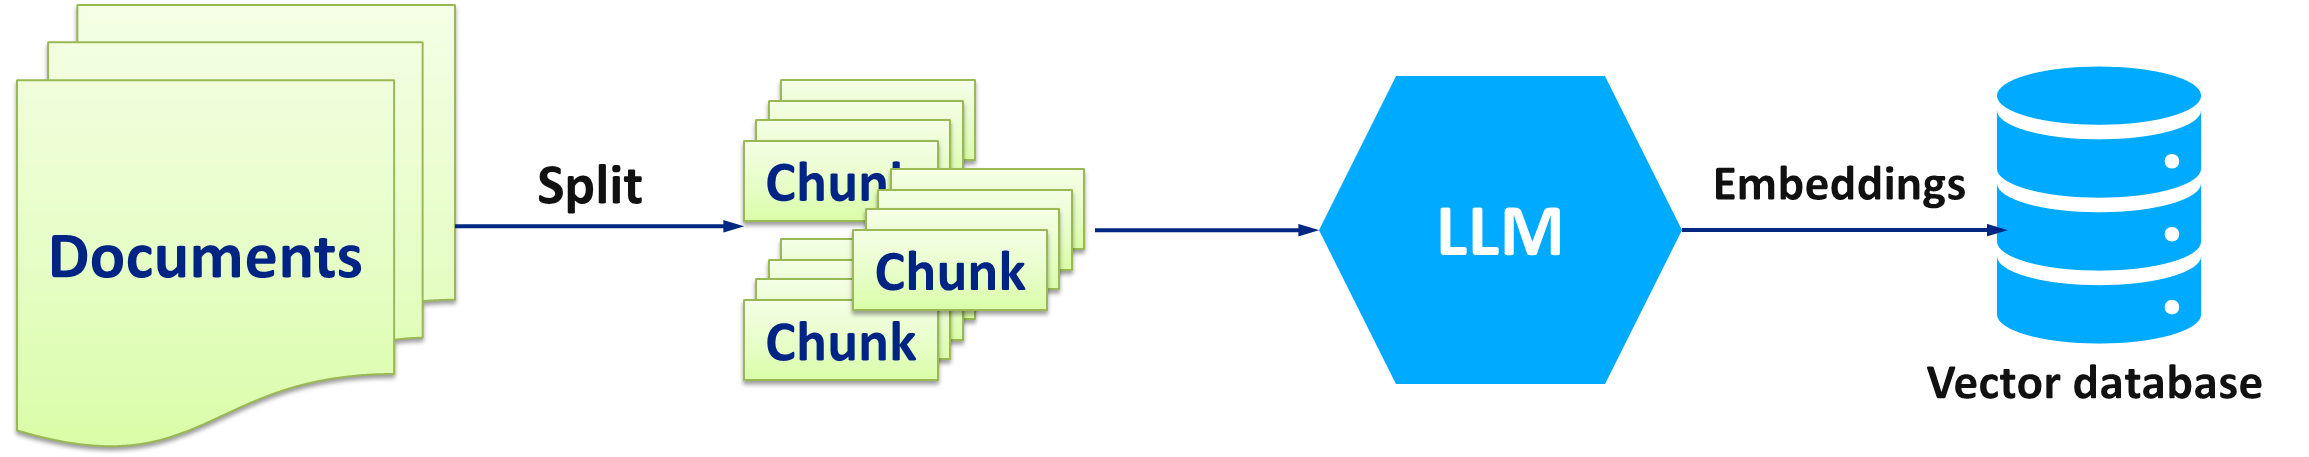

3. **Retrieval**: Run a user query (prompt) though a LLM and select chunks that are most relevant to a user’s query from the vector database.

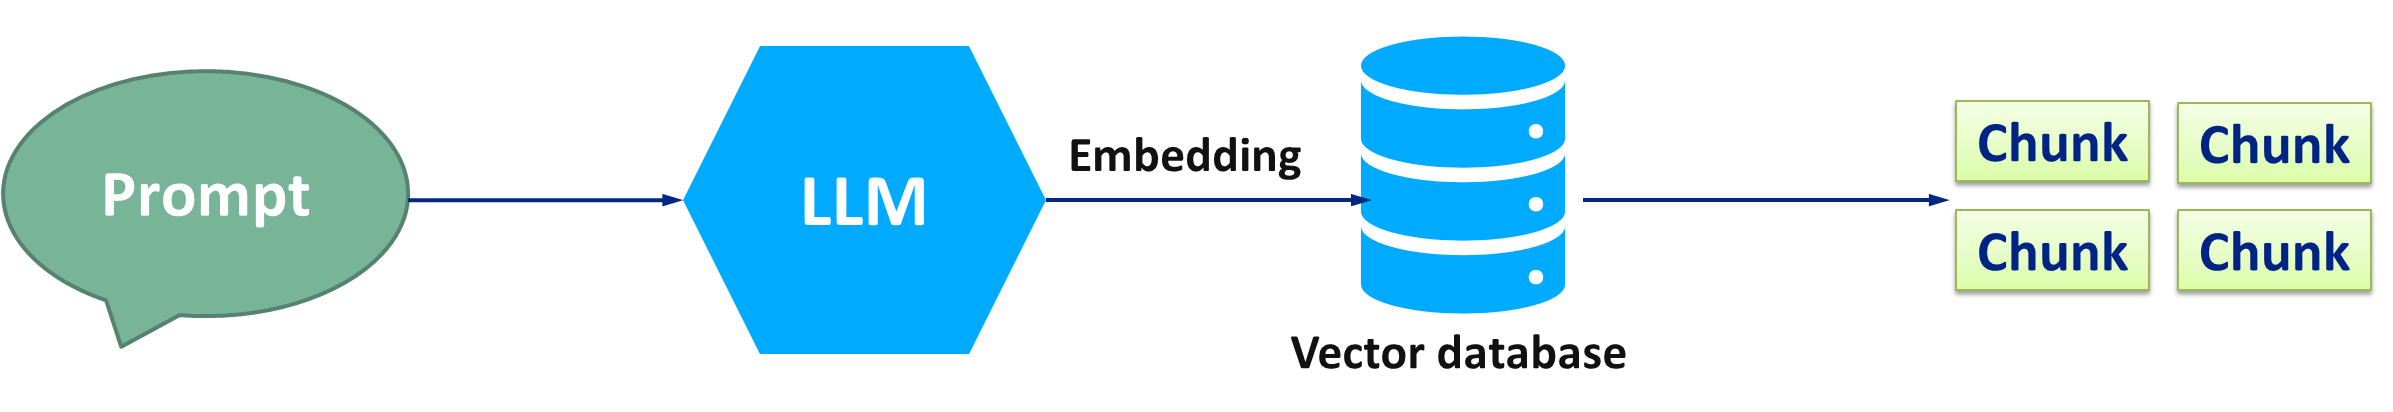

4. **Generation**: The LLM generates responses based on both the query and the retrieved chunks, producing a more contextually relevant answer.

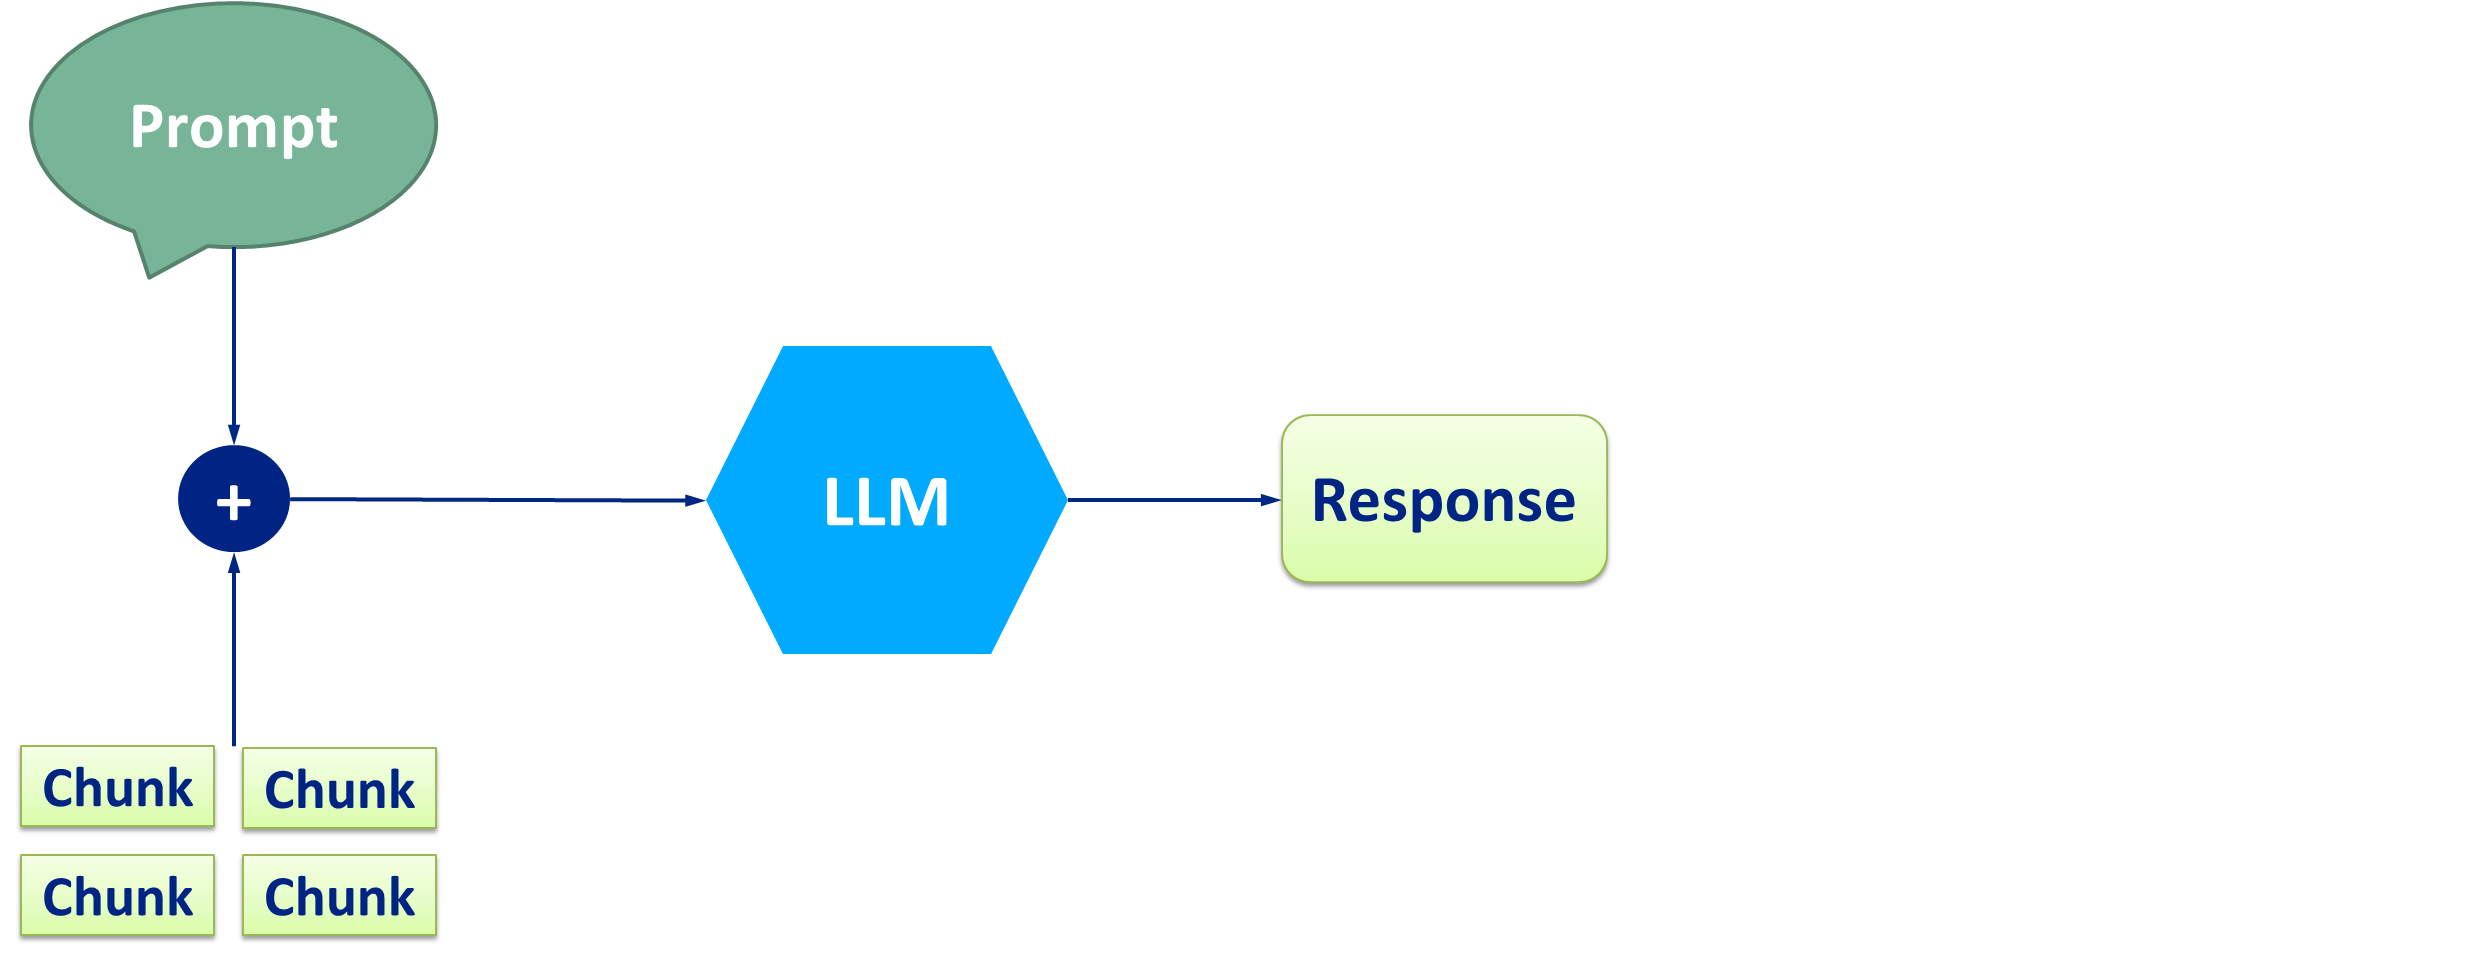

### Part 2: Introduction to LangChain

**LangChain** is a framework that helps developers build applications using LLMs. It supports chaining together various components such as retrieval mechanisms, prompt templates, and LLM queries into a coherent pipeline. You will use LangChain to integrate the LLM and document retrieval system into a single workflow. Langchain consists of several components:

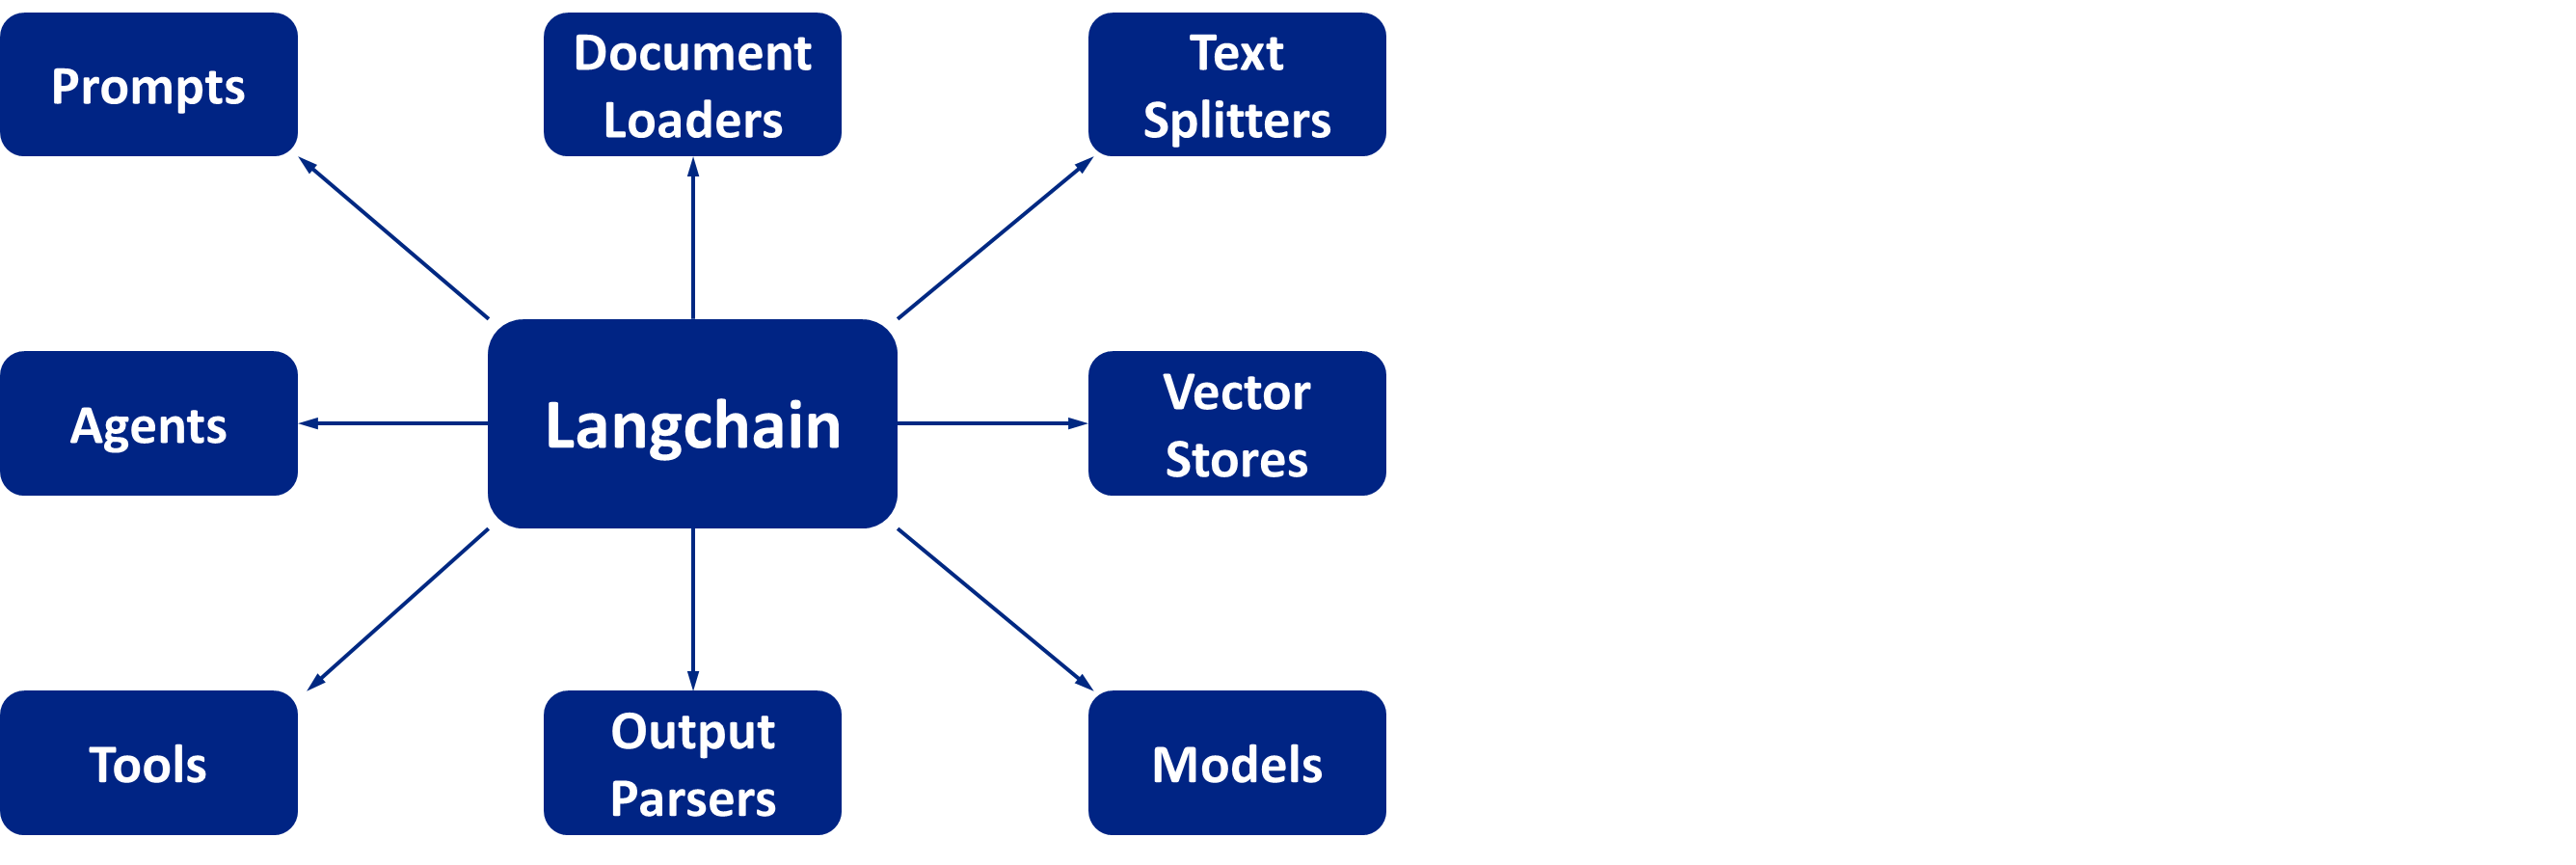

All components can be combined into **chains**. A **chain** is a sequence of component calls.

The **chain** itself is also a component, so simple chains can be used to form more complex сhains.

Here’s a simple example using the Langchain framework that demonstrates some of its basic components. In this example, we create a prompt template for a language model to generate a greeting based on a user’s name and mood.

Installation of necessary libraries:
```bash
%pip install langchain langchain_community yandexcloud
```
Example:
```python
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.llms import YandexGPT

# Step 1: Create a prompt template.
# The template is parameterized with `name` and `mood` variables, which can be
# passed from another source, for example, from a mobile application or web page.
prompt_template = PromptTemplate(
    template="Create a friendly greeting for someone named {name} who is feeling {mood}.",
    input_variables=["name", "mood"]
)

# Step 2: Initialize the language model (LLM).
# Usually, keys for the language model are provided by the vendor after payment.
# But if you have your own resources to run heavy models, then you can get the
# HuggingFace models using the classes `HuggingFacePipeline` and `HuggingFaceEmbeddings`.
llm = YandexGPT(api_key="your-key", folder_id="your-folder-id")

# Step 3: Set up the output parser
output_parser = StrOutputParser()

# Step 4: Combine components into a runnable chain with two parameters.
# A chain of components is created using the "pipe" operator "|".
greeting_runnable = (
    {
        "name": RunnablePassthrough(),  # param1
        "mood": RunnablePassthrough()   # param2
    }
    | prompt_template
    | llm
    | output_parser
)

# Step 5: Run the chain with sample input.
# The chain and each component in it implement the `invoke(str)` method,
# which takes the input parameters and their values in the form of a dictionary.
input_data = {"name": "Alice", "mood": "happy"}
greeting = greeting_runnable.invoke(input_data)

# Step 6: Print the output
print(greeting)
```

Components explanation:
* `RunnablePassthrough`: This component allows you to pass data through without any transformation. It’s useful as a placeholder in the pipeline.
* `PromptTemplate`: This component is responsible for formatting the input text to be sent to the language model. In this case, it uses variables `name` and `mood` to create a greeting prompt.
* `LLM` (YandexGPT): This is the language model we are using to generate text. You can adjust the temperature parameter to control the randomness of the output.
* `StrOutputParser`: This parses the string output from the language model into a more structured format, if needed. In this case, it simply returns the string output directly.

To create questions generation and RAG pipelines you may need the following components:

1. Prompts:
    * ```langchain_core.prompts.PromptTemplate```
2. Document Loaders:
    * ```langchain.document_loaders.DirectoryLoader```
    * ```langchain.document_loaders.PyMuPDFLoader```
3. Text Splitters:
    * ```langchain_text_splitters.RecursiveCharacterTextSplitter```
4. Vector Stores:
    * ```langchain_chroma.Chroma```
5. Models:
    * ```langchain_community.embeddings.yandex.YandexGPTEmbeddings```
    * ```langchain_community.llms.YandexGPT```
6. Models:
    * ```langchain_core.output_parsers.StrOutputParser```
7. Runnables:
    * ```langchain_core.runnables.RunnablePassthrough```

Here are some useful links to documentation where you can find hints regarding the implementation of the pipelines:

* <a href="https://python.langchain.com/v0.2/docs/tutorials/llm_chain/">Simple LLM</a>
* <a href="https://python.langchain.com/v0.2/docs/tutorials/retrievers/">Vector Stores and Retrievers</a>
* <a href="https://python.langchain.com/v0.2/docs/tutorials/rag/">RAG example</a>
* <a href="https://python.langchain.com/v0.2/docs/tutorials/">List of tutorials</a>
* <a href="https://python.langchain.com/v0.2/docs/introduction/">Langchain Into</a>
* <a href="https://python.langchain.com/docs/integrations/text_embedding/yandex/">YandexGPT Embeddings</a>
* <a href="https://python.langchain.com/docs/integrations/llms/yandex/">YandexGPT LLM</a>

### Part 3: Step-by-Step Implementation

1. **Download Articles**:
   - Download the articles you like automatically. Use python libraries like `requests`, `urllib` or others.

2. **Formulate Questions**:
   - For each article, read the content and come up with one relevant question. Make a list of them.

3. **Implement a Questions Generation Pipeline**:
   - Use LangChain to create a pipeline that processes each article and generates three additional questions.
   - Typically, articles are very long and may not fit into the LLM along with the prompt. In this case, additional document processing steps can help: splitting into chunks, summarizing, etc. Be creative and come up with your own approach.

4. **Implement the RAG Pipeline**:
   - Split documents into chunks. LangChain text splitters may help.
   - Set up the retrieval mechanism using LangChain. This can be done by indexing the chunks using LangChain’s `Chroma` component to retrieve relevant documents based on a query.
   - Create retriever, prompt, llm, and combine them into the chain.

5. **Test**:
   - Test your RAG pipeline on all questions (both created by you and generated).
   - Print question-answer pairs and evaluate whether the answers make sense given the articles.

### Part 4: Submission Requirements
1. There is no late submission for this assignment.
2. It is individual work.
3. Submit a Jupyter notebook (.ipynb file) to the Teams Assignment.
4. The notebook should contain:
   - The code for downloading and processing documents.
   - Your implementation of the LangChain pipeline for questions generation.
   - The implementation of the RAG pipeline using LangChain and YandexGPT.
   - Questions, both created by you and generated.
   - Answers generated by your RAG pipeline.
5. Grading: 0-25% of the course.

### Additional Resources:
- [LangChain Documentation](https://langchain.com/docs/)
- [YandexGPT API Documentation](https://yandex.cloud/en/docs/foundation-models/)
- [Arxiv.org](https://arxiv.org)
- [Papers with Code](https://paperswithcode.com)

---

This project will help you understand how retrieval-augmented generation can be applied to real-world business cases, enabling you to integrate powerful language models into knowledge-intensive applications.

Good luck!

**TASK 1:** dowloaded 10 articles from https://arxiv.org/ using API

In [1]:
%pip install langchain langchain_community langchain_chroma pymupdf yandexcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 628.3/628.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 22.7 MB/s eta 0:00:00
   ━

In [14]:
articles = ['https://arxiv.org/pdf/2412.14173',
            'https://arxiv.org/pdf/2412.14169',
            'https://arxiv.org/pdf/2412.14170',
            'https://arxiv.org/pdf/2412.14172',
            'https://arxiv.org/pdf/2412.14166',
            'https://arxiv.org/pdf/2412.14162',
            'https://arxiv.org/pdf/2412.14171',
            'https://arxiv.org/pdf/2412.14167']

In [ ]:
import os
import requests

download_folder = "arxiv_articles"
os.makedirs(download_folder, exist_ok=True)

# dowloading PDF-file
def download_pdf(url):
    response = requests.get(url)

    if response.status_code == 200:
        # get name and url of the file
        filename = os.path.join(download_folder, url.split('/')[-1] + '.pdf')

        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed to download: {url}")

for article in articles:
    download_pdf(article)

Downloaded: arxiv_articles/2412.14173.pdf
Downloaded: arxiv_articles/2412.14169.pdf
Downloaded: arxiv_articles/2412.14170.pdf
Downloaded: arxiv_articles/2412.14172.pdf
Downloaded: arxiv_articles/2412.14166.pdf
Downloaded: arxiv_articles/2412.14162.pdf
Downloaded: arxiv_articles/2412.14171.pdf
Downloaded: arxiv_articles/2412.14167.pdf


**TASK 2:**

In [30]:
my_questions = [
    "What are the key challenges addressed by the AniDoc model in automating the process of 2D animation production, and how does it improve the efficiency and quality of colorization in animated videos?",
    "What are the key innovations and advantages of the NOVA model in text-to-video and text-to-image generation?",
    "What are the key innovations introduced by the E-CAR model to enhance the efficiency of autoregressive image generation?",
    "How does the use of massive Internet videos enhance the generalization ability of the humanoid pose control method compared to traditional motion generation models?",
    "What are the implications of training models solely on MegaSynth, and how do they compare to models trained on real data?",
    "What are the key challenges and implications of applying Effective Field Theories (EFTs) to Drell-Yan processes at the LHC, especially concerning the validity range and the role of higher-dimensional operators?",
    "What does the analysis of self-explanations reveal about the factors affecting MLLMs' performance on VSI-Bench?",
    "What improvements were observed after training with VideoDPO on the models evaluated?"
]

**TASK 3:**

In [17]:
!pip install "unstructured[pdf]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.9/586.9 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.6/514.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 85.7 MB/s et

In [1]:
import os
from langchain.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.llms import YandexGPT

/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_uri" in _BaseYandexGPT has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in _BaseYandexGPT has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_version" in _BaseYandexGPT has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


In [ ]:
ARTICLE_DIRECTORY = "/content/arxiv_articles"

loader = DirectoryLoader(
    ARTICLE_DIRECTORY,
    glob="**/*.pdf", 
    loader_cls=PyMuPDFLoader  
)

documents = loader.load()

In [3]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500, chunk_overlap=200
)

In [ ]:
#Step 1: Initialize the model
llm = YandexGPT(api_key="", folder_id="")

In [5]:
#Step 2: Create a prompt template.
prompt_template = PromptTemplate(
    template="Based on the article create three meaningful questions in English about the following text. "
             "The questions must be written in English regardless of the language of the source text: {text}",
    input_variables=["text"]
)


In [6]:
# Step 3: Set up the output parser
output_parser = StrOutputParser()

In [7]:
# Step 4: Combine components into a runnable chain with one parameter
question_runnable = (
    {
        "text": RunnablePassthrough()
    }
    | prompt_template
    | llm
    | output_parser
)

In [8]:
print(documents[0].metadata)

{'source': '/content/arxiv_articles/2412.14172.pdf', 'file_path': '/content/arxiv_articles/2412.14172.pdf', 'page': 0, 'total_pages': 35, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': 'LaTeX with hyperref', 'producer': 'pdfTeX-1.40.25', 'creationDate': 'D:20241219021032Z', 'modDate': 'D:20241219021032Z', 'trapped': ''}


In [ ]:
import random

title_question_pairs = []

for document in documents:
    title = document.metadata['source']
    chunks = text_splitter.split_documents([document])  # split each article to chunks
    # select three random chunks
    selected_chunks = random.sample(chunks, min(3, len(chunks)))

    for chunk in selected_chunks:
        questions = question_runnable.invoke({"text": chunk.page_content})
        title_question_pairs.append((title, questions))  # add source and questions into list 


for title, questions in title_question_pairs:
    print(f"Title: {title}\nQuestions:\n{questions}\n")


Title: /content/arxiv_articles/2412.14172.pdf
Questions:
1. What is Humanoid-X and what purpose does it serve?
2. How is Humanoid-X different from traditional approaches to learning humanoid robots?
3. What challenges does the paper identify in the current approaches to training humanoid robots, and how does Humanoid-X aim to address these challenges?

Title: /content/arxiv_articles/2412.14172.pdf
Questions:
1. How is the Humanoid-X pipeline designed to collect and process data for training humanoid robots?
2. What is the purpose of the large humanoid model UH-1, and how does it function?
3. How have simulated and real-world experiments validated the effectiveness of the scalable training approach used in the development of Humanoid-X?

Title: /content/arxiv_articles/2412.14172.pdf
Questions:
1. How can learning affordances, flows and world models from natural videos improve the scalability of robot learning?
2. What are the main challenges in using videos as demonstrations for robot l

In [10]:
for i in title_question_pairs:
    print(i[0])

/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2412.14172.pdf
/content/arxiv_articles/2

In [11]:
sources = []
for document in documents:
    sources.append(document.metadata['source'])
unique_values = list(set(sources))
unique_values

['/content/arxiv_articles/2412.14173.pdf',
 '/content/arxiv_articles/2412.14169.pdf',
 '/content/arxiv_articles/2412.14166.pdf',
 '/content/arxiv_articles/2412.14162.pdf',
 '/content/arxiv_articles/2412.14167.pdf',
 '/content/arxiv_articles/2412.14170.pdf',
 '/content/arxiv_articles/2412.14171.pdf',
 '/content/arxiv_articles/2412.14172.pdf']

In [ ]:
grouped_questions = {}

for title, questions_str in title_question_pairs:
    questions = questions_str.split('\n')
    questions = [q.strip() for q in questions if q.strip()]

    if title not in grouped_questions:
        grouped_questions[title] = []

    grouped_questions[title].extend(questions)

for title, questions in grouped_questions.items():
    print(f"Title: {title}\nQuestions: {questions}\n")

Title: /content/arxiv_articles/2412.14172.pdf
Questions: ['1. What is Humanoid-X and what purpose does it serve?', '2. How is Humanoid-X different from traditional approaches to learning humanoid robots?', '3. What challenges does the paper identify in the current approaches to training humanoid robots, and how does Humanoid-X aim to address these challenges?', '1. How is the Humanoid-X pipeline designed to collect and process data for training humanoid robots?', '2. What is the purpose of the large humanoid model UH-1, and how does it function?', '3. How have simulated and real-world experiments validated the effectiveness of the scalable training approach used in the development of Humanoid-X?', '1. How can learning affordances, flows and world models from natural videos improve the scalability of robot learning?', '2. What are the main challenges in using videos as demonstrations for robot learning?', '3. What are the potential applications of improving the scalability of robot lear

In [13]:
grouped_questions

{'/content/arxiv_articles/2412.14172.pdf': ['1. What is Humanoid-X and what purpose does it serve?',
  '2. How is Humanoid-X different from traditional approaches to learning humanoid robots?',
  '3. What challenges does the paper identify in the current approaches to training humanoid robots, and how does Humanoid-X aim to address these challenges?',
  '1. How is the Humanoid-X pipeline designed to collect and process data for training humanoid robots?',
  '2. What is the purpose of the large humanoid model UH-1, and how does it function?',
  '3. How have simulated and real-world experiments validated the effectiveness of the scalable training approach used in the development of Humanoid-X?',
  '1. How can learning affordances, flows and world models from natural videos improve the scalability of robot learning?',
  '2. What are the main challenges in using videos as demonstrations for robot learning?',
  '3. What are the potential applications of improving the scalability of robot le

In [ ]:
#random choice of three questions generated per article
import random
random.seed(42)
articles_questions = {}
for i in grouped_questions.keys():
    articles_questions[i] = random.choices(grouped_questions[i], k=3)
articles_questions

{'/content/arxiv_articles/2412.14172.pdf': ['3. How is the goal-conditioned control policy trained in the text?',
  '1. How can learning affordances, flows and world models from natural videos improve the scalability of robot learning?',
  '2. What are the two stages of the pipeline proposed in the article for generating humanoid actions from text?'],
 '/content/arxiv_articles/2412.14167.pdf': ['2. What is DiffusionDPO and how does it adapt DPO for text-to-image diffusion models?',
  '2. How does the T2v-turbo model overcome the quality bottleneck of video consistency models?',
  '3. What are the potential applications of the techniques described in the text in the field of video generation?'],
 '/content/arxiv_articles/2412.14169.pdf': ['3. Why do the generated frames start to deviate from the ground truth after a few iterations?',
  '1. How long did it take to train the NOVA model on A100-40G?',
  '1. How does the performance of SOTA model Emu3 compare to other state-of-the-art diffu

In [ ]:
for key in articles_questions:
    articles_questions[key] = [question.split('. ', 1)[1] if '. ' in question else question for question in articles_questions[key]]

articles_questions

{'/content/arxiv_articles/2412.14172.pdf': ['How is the goal-conditioned control policy trained in the text?',
  'How can learning affordances, flows and world models from natural videos improve the scalability of robot learning?',
  'What are the two stages of the pipeline proposed in the article for generating humanoid actions from text?'],
 '/content/arxiv_articles/2412.14167.pdf': ['What is DiffusionDPO and how does it adapt DPO for text-to-image diffusion models?',
  'How does the T2v-turbo model overcome the quality bottleneck of video consistency models?',
  'What are the potential applications of the techniques described in the text in the field of video generation?'],
 '/content/arxiv_articles/2412.14169.pdf': ['Why do the generated frames start to deviate from the ground truth after a few iterations?',
  'How long did it take to train the NOVA model on A100-40G?',
  'How does the performance of SOTA model Emu3 compare to other state-of-the-art diffusion models in terms of qua

**TASK 4:** Building RAG pipeline with the use of LLM YandexGPT

In [35]:
from langchain.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.llms import YandexGPT
from langchain_community.embeddings.yandex import YandexGPTEmbeddings
from langchain.vectorstores import Chroma
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain.chains import RetrievalQA
import os

In [36]:
def load_articles(directory):
    # Use DirectoryLoader once for the entire directory
    # (not inside a loop) to avoid loading duplicate documents
    loader = DirectoryLoader(
        directory,
        glob="**/*.pdf",
        loader_cls=PyMuPDFLoader
    )
    documents = loader.load()
    return documents


documents = load_articles('/content/arxiv_articles')


In [37]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500, chunk_overlap=200
)
chunks = text_splitter.split_documents(documents)

In [ ]:
embeddings = YandexGPTEmbeddings(api_key='AQVNyn4rU6PadBTSi1refjdSJQemBplhCvBqSohU', folder_id="b1g2ob2n9sqlmmgmvig3")
vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings)

KeyboardInterrupt: 

In [39]:
from langchain.llms import HuggingFaceHub
from langchain.embeddings import HuggingFaceEmbeddings

In [40]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma.from_documents(chunks, embeddings)

In [41]:
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 6})

In [71]:
llm = YandexGPT(api_key="AQVNyn4rU6PadBTSi1refjdSJQemBplhCvBqSohU", folder_id="b1g2ob2n9sqlmmgmvig3")

In [72]:
prompt_template = PromptTemplate(
    template="""You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know.
    Context: {context}
    Question: {question}
    Answer: """,
    input_variables=["context", "question"]
)

In [73]:
output_parser = StrOutputParser()

In [74]:
question_runnable = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt_template
    | llm
    | output_parser
)

In [75]:
def get_answers(questions):
    answers = {}
    for question in questions:
        answer = question_runnable.invoke(question)
        answers[question] = answer
    return answers

In [32]:
manual_answers = get_answers(my_questions)

print("Manual Answers:")
for question, answer in manual_answers.items():
    print(f"{question} \n {answer}")
    print("-------------------------")

Manual Answers:
What are the key challenges addressed by the AniDoc model in automating the process of 2D animation production, and how does it improve the efficiency and quality of colorization in animated videos? 
 The AniDoc model addresses the key challenges of automating the process of 2D animation production by improving the efficiency and quality of colourisation in animated videos.

It achieves this through:

* **Consistent colourisation across different video clips:** even when the sketches differ significantly in terms of pose or scale, the model can generate consistent colourisations.
* **Preserving the identity of the character while adapting the finer details:** when applying different reference images to the same sketch sequence, the model can preserve the identity of the character while adapting the lighting and background.

This results in high-quality colourisation results, as demonstrated by the use of reconstruction metrics including PSNR, SSIM, and LPIPS.
----------

In [79]:
for questions in articles_questions.values():
        auto_answers = get_answers(questions)
        print("Automated questions answers:")
        for question, answer in auto_answers.items():
            print(f"{question} \n {answer}")
            print("-------------------------")

Automated questions answers:
How is the goal-conditioned control policy trained in the text? 
 The goal-conditioned control policy is trained by auto-regressively decoding action tokens Ztoken conditioned on text commands T.
-------------------------
How can learning affordances, flows and world models from natural videos improve the scalability of robot learning? 
 Learning affordances, flows and world models from natural videos can improve the scalability of robot learning by providing valuable representations from massive visual data that can be transferred to robotic tasks. This approach allows for the development of more generalizable and scalable robot learning policies.
-------------------------
What are the two stages of the pipeline proposed in the article for generating humanoid actions from text? 
 1. Генерация высокоуровневых человекоподобных ключевых точек (text-to-keypoint) для управления человекоподобным роботом в замкнутом цикле.
2. Генерация роботизированных действий (